reducir variables numéricas y visualizar patrones en 2 dimensiones.


DATASET LIMPIO

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/dataset_limpio.csv")
df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Standard,805.8,Brasil,Crime,2025-03-04,99
1,10001,37,Standard,1173.4,Colombia,Crime,2019-04-02,2
2,10002,28,Basic,401.0,Colombia,Crime,2018-04-13,0
3,10003,43,Basic,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Basic,477.8,Perú,Thriller,2020-09-30,1


SELECCIÓN DE VARIABLES NUMÉRICAS

In [2]:
df_num = df[[
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets"
]]

Se seleccionan únicamente variables numéricas relevantes para PCA, excluyendo variables categóricas e identificadores, ya que estos no aportan información útil para la reducción de dimensionalidad.

ESCALAMIENTO

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

Se aplica estandarización para transformar las variables a media 0 y desviación estándar 1, asegurando que todas tengan la misma escala y evitando que una variable domine el análisis.

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(df_scaled)

Se aplica PCA para reducir la dimensionalidad del dataset a dos componentes principales, conservando la mayor cantidad posible de información.

In [5]:
df_pca = pd.DataFrame(components, columns=["PC1", "PC2"])
df_pca.head()

,PC1,PC2
0,-4.730720,5.353551
1,0.095416,0.167760
2,-0.199218,-0.421230
3,0.253722,0.406414
4,0.520344,0.892677


Se genera un nuevo dataset con las dos componentes principales, que representan una versión comprimida de la información original.

In [6]:
pca.explained_variance_ratio_

array([0.33508409, 0.33298291])

Las componentes principales explican una proporción significativa de la varianza del dataset, lo que indica que la reducción de dimensionalidad es efectiva sin pérdida crítica de información.

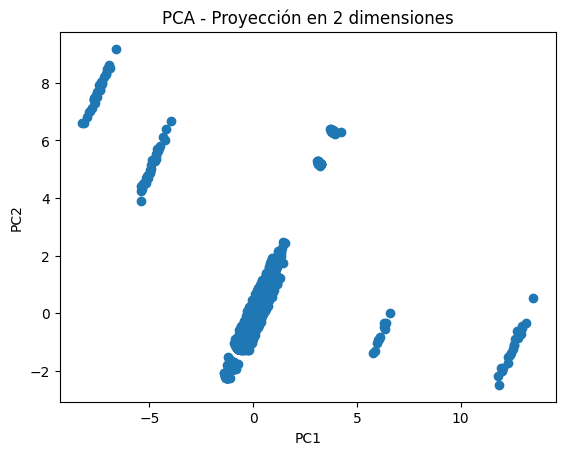

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df_pca["PC1"], df_pca["PC2"])
plt.title("PCA - Proyección en 2 dimensiones")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

El gráfico permite visualizar la distribución de los datos en un espacio reducido, facilitando la identificación de patrones o agrupaciones generales entre usuarios.

In [8]:
import numpy as np

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df_num.columns
)

loadings

,PC1,PC2
age,0.481109,0.799416
monthly_watch_time_mins,0.665544,-0.065920
customer_support_tickets,-0.570601,0.597150


Se observa qué variables tienen mayor influencia en cada componente principal, permitiendo entender qué factores explican mejor la variabilidad de los datos.

CONCLUSION
El análisis de componentes principales permitió reducir la dimensionalidad del dataset a dos variables principales, manteniendo una proporción significativa de la información original.

Esto facilita la visualización y comprensión de los datos, sin perder patrones importantes del comportamiento de los usuarios.

Se observa que las variables numéricas seleccionadas contienen información suficiente para representar el dataset en un espacio reducido.
""")